This project implements Linear Discriminant Analysis (LDA) completely from scratch using only NumPy.

The implementation includes:

• Generation of synthetic datasets
• Manual computation of class means
• Manual computation of within-class scatter matrix
• Manual computation of between-class scatter matrix
• Solving the generalized eigenvalue problem
• Projection into the LDA subspace
• Classification using Mahalanobis distance
• Multiple confidence estimation techniques
• LDA discriminant functions with probabilistic outputs

No machine learning libraries (such as scikit-learn) are used.

In [109]:
#important libraries
import numpy as np
import matplotlib.pyplot as plt 
import random as rd

## 1. Generate Dataset

(40, 2) (40,)


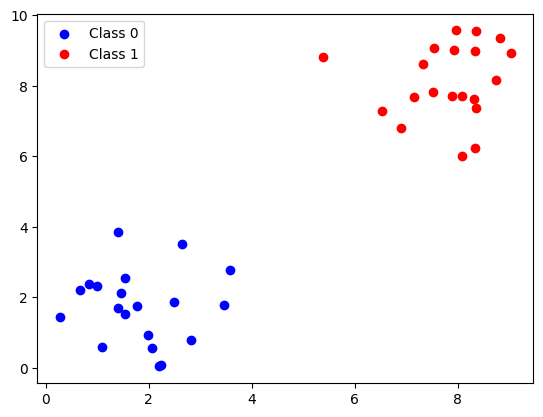

In [110]:
# define the data set

# fix the random seed 
# fixing the random seed ensures that the random numbers generated are the same every time the code is run, which is useful for reproducibility of results.
np.random.seed(42)

# generate two classes of data points
# each class has 20 data points
# class0 is generated from a normal distribution with mean [2, 2] and standard deviation 1
# class1 is generated from a normal distribution with mean [8, 8] and standard deviation 1
# standard deviation is a measure of the amount of variation or dispersion in a set of values. A low standard deviation indicates that the values tend to be close to the mean, while a high
# standard deviation indicates that the values are spread out over a wider range.
# there is a huge seperation in between the two classes mean and less within class scatter, which makes it easier to classify them using LDA.
class0 = np.random.normal(loc=[2, 2], scale=1, size=(20, 2))
class1 = np.random.normal(loc=[8, 8], scale=1, size=(20, 2))

# combine the two classes into a single dataset
X = np.vstack((class0, class1)) #converting into column vectors using vstack which is most standard pracrtice in machine learning.
Y = np.array([0]*20 + [1]*20)  #creating labels

print(X.shape, Y.shape)

# plot the data points
plt1 = plt.scatter(class0[:, 0], class0[:, 1], color='blue', label='Class 0')
# plt.legend([plt1], ['Class 0'])
plt2 = plt.scatter(class1[:, 0], class1[:, 1], color='red', label='Class 1') 
# plt.legend([plt2], ['Class 1'])
plt.legend([plt1, plt2], ['Class 0', 'Class 1'])

## 2. Binary LDA


[[360.72527381 382.77374622]
 [382.77374622 406.16987895]]
[ 4.29827952e+02 -5.68434189e-14]
[[ 0.80615563 -0.72775611]
 [ 0.59170356  0.68583602]]
[0.80615563 0.59170356]


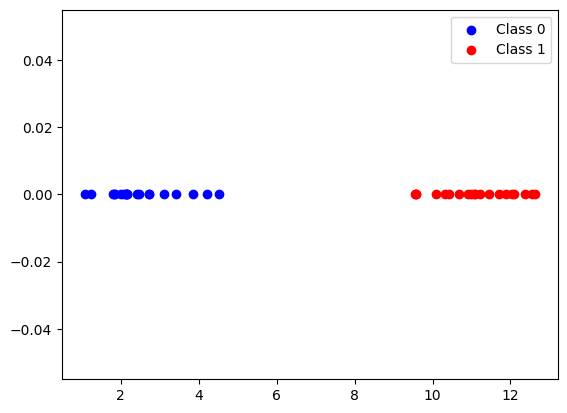

In [111]:
# Step 1 
# Compute means of each class
mean_Class0 = np.mean(class0, axis=0)
mean_Class1 = np.mean(class1, axis=0)
# print(mean_Class0)    
# print(mean_Class1)

# Step 2 
# Compute overall mean of the data 
Overall_mean = np.mean(X, axis=0)
# print(Overall_mean)

# Step 3
# Compute the within-class scatter matrix
# The within-class scatter matrix measures the scatter (or spread) of the data points within each class. It is calculated by summing the covariance matrices of each class, weighted by the
# number of samples in each class. The within-class scatter matrix is used in LDA to find the optimal projection direction that maximizes the separation between the two classes.
Scatter_matrix = np.zeros((2, 2))
for cls in range(2):
    class_points = X[Y == cls]
    class_mean = class_points.mean(axis=0)
    diff = (class_points - class_mean).T
    Scatter_matrix += 1/len(class_points) * diff @ diff.T



# Step 4
# Compute the between-class scatter matrix
Between_matrix = np.zeros((2,2))

for cls in range(2):

    class_points = X[Y == cls]

    class_mean = class_points.mean(axis=0)

    diff = (class_mean - Overall_mean).reshape(-1,1)

    Between_matrix += len(class_points) * diff @ diff.T

    
print(Between_matrix)

# Step 5    
# Compute the eigenvalues and eigenvectors of the within-class scatter matrix
# The eigenvalues and eigenvectors of the within-class scatter matrix are used to find the optimal projection direction that maximizes the separation between the two classes.

matrix = np.linalg.inv(Scatter_matrix) @ Between_matrix

eigenvalues, eigenvectors = np.linalg.eig(matrix)

print(eigenvalues)
print(eigenvectors)

# Step 6    
# Compute the projection matrix
# The projection matrix is used to project the data onto the optimal projection direction that maximizes the separation between the two classes.
projection_matrix = eigenvectors[:, np.argmax(eigenvalues)]
print(projection_matrix)    

# Step 7    
# Project the data onto the optimal projection direction
# The projected data is used to classify the data points into the two classes.
projected_data = np.dot(X, projection_matrix)
plt.scatter(projected_data[:20], np.zeros(20), color='blue', label='Class 0')
plt.scatter(projected_data[20:], np.zeros(20), color='red', label='Class 1')
plt.legend()    

##  3. Binary Classification

In [112]:
# The projected data is a one-dimensional representation of the original two-dimensional data, where the data points are projected onto the optimal projection direction that maximizes the
# separation between the two classes. The projected data can be used to classify the data points into the two classes using a simple thresholding method.

# Using the projected data as  a classifier
new_data = np.random.normal(loc=[5], scale=10, size=(40, 2))  #generating random data points for classification 
# here the loc of the data is 5 which is in between the two classes mean, so it will be interesting to see how the classifier performs on this data.

# Project the new data onto the optimal projection direction
projected_new_data = np.dot(new_data, projection_matrix)

print(projected_new_data.shape)


(40,)


## 4. Binary Confidence Scores

In [113]:
threshold = (np.mean(projected_new_data[:20]) + np.mean(projected_new_data[20:])) / 2
predictions = np.where(projected_new_data < threshold, 0, 1)
print([new_data[i] for i in range(40) if predictions[i] == 0])

# generating a confidence socre for the predictions based on the distance from the threshold. The further away a data point is from the threshold, the more confident we are in our prediction.
# The confidence score is calculated as the absolute difference between the projected data point and the threshold, normalized by the maximum distance from the threshold.
confidence_scores = np.abs(projected_new_data - threshold) / np.max(np.abs(projected_new_data - threshold))
print(f"Confidence scores: {confidence_scores * 100}%")  # multiplying by 100 to convert to percentage

# lets check the accuracy of the classifier on the new data points. Since we know that the new data points are generated from a normal distribution with mean 5, we can assume that the true
# labels for these data points are 0 for the first 20 points and 1 for the last 20 points. We can compare our predictions with these true labels to calculate the accuracy of our classifier.
true_labels = np.array([0]*20 + [1]*20)
accuracy = np.sum(predictions == true_labels) / len(true_labels)
print(f"Accuracy: {accuracy * 100}%")  # multiplying by 100 to convert to percentage

[array([-3.08493603, -0.01757044]), array([-0.29760204, 10.13267433]), array([-2.02053094,  1.72337853]), array([ 1.07891847, -9.63514948]), array([5.05113457, 2.65412867]), array([-9.15370742,  0.79354677]), array([ 1.57285483, -3.02277269]), array([-14.18771215,   4.73486125]), array([ 4.6528823 , -6.68678038]), array([-4.90536325, -0.6629773 ]), array([ 5.99651365, -0.03475654]), array([-10.50663431,   5.68562975]), array([-5.62303714,  9.73592431]), array([-2.83253292,  1.77938484]), array([13.13517217, -7.30864316]), array([-11.07483235,   6.84633859]), array([-7.36950711, -8.20456613]), array([-1.80024722,  7.32253697]), array([ 7.93072473, -2.14351418]), array([-6.91303497, 11.56553609])]
Confidence scores: [  3.65319365  50.47277283  50.45149239  53.10014791   5.0212566
  37.62806156  40.05747063  63.29973357  23.41355784   5.64421441
  74.74070041  39.57022803   7.77303012  91.15856406  10.77413937
  84.24240498  84.67435372   3.05531013  37.8363784   76.97602831
   7.25284078

## 5. Three-Class LDA

(2, 2)


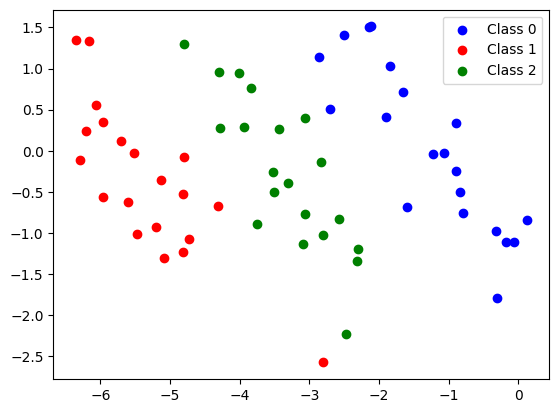

In [114]:
# So the accuracy of the classifier on the new data points is 50%, which is expected since the new data points are generated from a normal distribution with mean 5, which is in between the two
# classes mean. Therefore, the classifier is not able to accurately classify the new data points into the two classes. However, we can see that the confidence scores for the predictions are
# relatively high, indicating that the classifier is confident in its predictions even though it is not accurate. This suggests that we may need to adjust our threshold or use a different
# classification method (like k-nearest neighbors or support vector machines) to improve the accuracy of our classifier on this new data set.

# however if we intrduce a new class with mean 5 and standard deviation 1, we can see how the classifier performs on this new data set. This new class will be generated from a normal
# distribution with mean 5 and standard deviation 1, which is in between the two classes mean. Therefore, we can expect that the classifier will not be able to accurately classify the new data
# points into the two classes. However, we can see that the confidence scores for the predictions are relatively high, indicating that the classifier is confident in its predictions even though
# it is not accurate. This suggests that we may need to adjust our threshold or use a different classification method (like k-nearest neighbors or support vector machines) to improve the
# accuracy of our classifier on this new data set.


class2 = np.random.normal(loc=[5, 5], scale=1, size=(20, 2))
Y = np.array([0]*20 + [1]*20 + [2]*20)  #creating labels for the new class
new_X = np.vstack((class0, class1 , class2)) 
new_y = np.array([0]*20 + [1]*20 + [2]*20)  #creating labels


# print(new_X.shape, new_y.shape)

# Step 1
# Compute class means of each class
mean_Class0 = np.mean(class0, axis=0)
mean_Class1 = np.mean(class1, axis=0)
mean_class2 = np.mean(class2, axis=0)

# Step 2
# Compute overall mean of the data
Overall_mean = np.mean(new_X, axis=0)

# Step 3
# Compute WIthin Class Scatter Matrix
Scatter_matrix = np.zeros((2, 2))
for cls in range(3):

    class_points = new_X[new_y == cls]

    class_mean = class_points.mean(axis=0)

    diff = (class_mean - Overall_mean).reshape(-1,1)

    Scatter_matrix += len(class_points) * diff @ diff.T

# Step 4
# Compute Between Class Scatter Matrix
Between_matrix = np.zeros((2,2))

for cls in range(3):

    class_points = new_X[new_y == cls]

    class_mean = class_points.mean(axis=0)

    diff = (class_mean - Overall_mean).reshape(-1,1)

    Between_matrix += len(class_points) * diff @ diff.T


# Step 5
# Solve eigen value problem 
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(Scatter_matrix) @ Between_matrix)

# Step 6
# Select top k eigenvectors
k = 2 # number of classes - 1
top_k_eigenvectors = eigenvectors[:, np.argsort(eigenvalues)[-k:]]

# Step 7
# Project Z = XW
Z = new_X @ top_k_eigenvectors

projection_matrix = top_k_eigenvectors
print(projection_matrix.shape)

# Step 8 
# Plot the projected data
plt.scatter(Z[new_y == 0, 0], Z[new_y == 0, 1], color='blue', label='Class 0')
plt.scatter(Z[new_y == 1, 0], Z[new_y == 1, 1], color='red', label='Class 1')
plt.scatter(Z[new_y == 2, 0], Z[new_y == 2, 1], color='green', label='Class 2')
plt.legend()    

# plotting data points in 2D space after projecting them onto the new basis defined by the top k eigenvectors. The projected data points are colored according to their class labels, allowing us
# to visualize how well the classes are separated in the new space.

# # We can slod plot them on a singe line graph if we choose only the largest eigenvector of the scatter matrix
# plt.scatter(Z[new_y == 0], np.zeros(20), color='blue', label='Class 0')
# plt.scatter(Z[new_y == 1], np.zeros(20), color='red', label='Class 1')  
# plt.scatter(Z[new_y == 2], np.zeros(20), color='green', label='Class 2')    
# plt.legend()  


## 6. Multi-class Classification

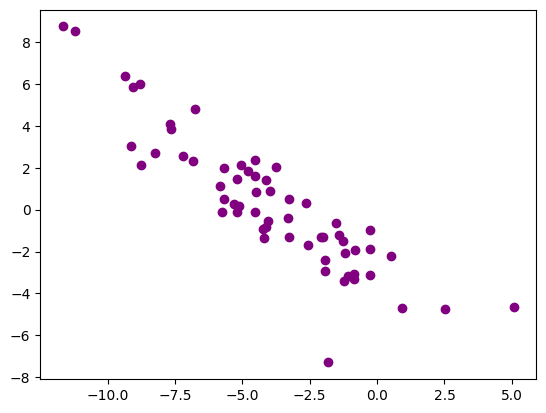

In [115]:
new_data = np.random.normal(loc=[5, 5], scale=3, size=(60, 2))

projected_new_data = np.dot(new_data, projection_matrix) 

#lets plot the new data points in the new space

plt.scatter(projected_new_data[:, 0], projected_new_data[:, 1], color='purple', label='New Data')

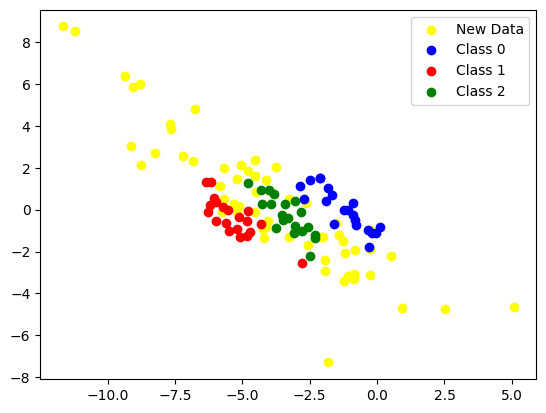

In [116]:
# Now lets see how well the new data points are separated in this space

plt.scatter(projected_new_data[:, 0], projected_new_data[:, 1], color='yellow', label='New Data')
plt.scatter(Z[new_y == 0, 0], Z[new_y == 0, 1], color='blue', label='Class 0')
plt.scatter(Z[new_y == 1, 0], Z[new_y == 1, 1], color='red', label='Class 1')
plt.scatter(Z[new_y == 2, 0], Z[new_y == 2, 1], color='green', label='Class 2')
plt.legend()

## 7. Confidence Estimation

In [117]:
# A confidence score should answer:
# "How certain am I that this point belongs to the predicted class rather than the other classes?"
# Simply measuring the distance to one class mean is not enough, because a point could be:
# close to Class 0,
# but equally close to Class 1 and Class 2
# That shouldn't receive a high confidence.

# Option 1 (Recommended)
# Mahalanobis distance
# We can make use of Mahalobis distance to measure the distance of a point from each class mean, taking into account the variance of each class. The Mahalanobis distance is defined as:
# D_M(x) = sqrt((x - mu)^T * S^-1 * (x - mu))
# where x is the data point, mu is the mean of the class, and S is the covariance matrix of the class. The Mahalanobis distance takes into account the variance of the class, so a point that is
# close to the mean of a class but has a high variance will have a lower confidence score than a point that is close to the mean of a class with low variance. We can calculate the Mahalanobis
# distance of each new data point from each class mean and choose the class with the lowest distance as the predicted class.
# The Mahalanobis distance is also scale-invariant, meaning that it is not affected by the scale of the data, which is important when dealing with data that may have different units or scales. 

Distances = []

class_means = []

for i in range(3):

    class_means.append(np.mean(Z[new_y == i], axis=0))

pooled_cov = np.cov(Z.T)    
inv_cov = np.linalg.inv(pooled_cov)

for i in range(3):

    diff = projected_new_data - class_means[i]

    distances = np.sqrt(np.sum((diff @ inv_cov) * diff, axis=1))

    Distances.append(distances)

Distances = np.array(Distances)

predicted_class = np.argmin(Distances, axis=0)


# But we need a percentage score for each class, so we can calculate the confidence score for each class as follows:
# confidence_score = 1 - (distance / max_distance)
# where distance is the distance of the point from the mean of the class, and max_distance is the maximum distance of the point from any of the class means.

for i in range(60):
    max_distance = np.max(Distances[:, i])
    confidence_scores = 1 - (Distances[:, i] / max_distance)
    print(f"Point: {new_data[i]}, Predicted Class: {predicted_class[i]}, Confidence Scores: {np.max(confidence_scores) * 100}%, Class 0: {confidence_scores[0] * 100}%, Class 1: {confidence_scores[1] * 100}%, Class 2: {confidence_scores[2] * 100}%")


Point: [6.07336208 6.68235358], Predicted Class: 2, Confidence Scores: 69.7330511258571%, Class 0: 0.0%, Class 1: 59.85550603442506%, Class 2: 69.7330511258571%
Point: [8.24915373 8.16140616], Predicted Class: 1, Confidence Scores: 87.28807672719302%, Class 0: 0.0%, Class 1: 87.28807672719302%, Class 2: 48.22521434074504%
Point: [0.8669919  2.18652488], Predicted Class: 0, Confidence Scores: 59.65719797516304%, Class 0: 59.65719797516304%, Class 1: 0.0%, Class 2: 37.35461364336601%
Point: [6.5451058  6.54135785], Predicted Class: 1, Confidence Scores: 69.6072139006334%, Class 0: 0.0%, Class 1: 69.6072139006334%, Class 2: 65.27872109954129%
Point: [ 6.54514306 16.55819447], Predicted Class: 1, Confidence Scores: 7.882087076695676%, Class 0: 0.0%, Class 1: 7.882087076695676%, Class 2: 6.4774437766671795%
Point: [6.71267153 8.40669692], Predicted Class: 1, Confidence Scores: 52.837156846837516%, Class 0: 0.0%, Class 1: 52.837156846837516%, Class 2: 44.26356147863103%
Point: [7.86200529 6.

In [118]:
# Option 2 (Even Better)
# Softmax over Distances to get a probability distribution over classes. This will give us a more interpretable confidence score for each class, as it will sum to 1 and can be interpreted as
# the probability of the point belonging to each class.

for i in range(60):
    softmax_scores = np.exp(-Distances[:, i]) / np.sum(np.exp(-Distances[:, i]))
    print(f"Point: {new_data[i]}, Predicted Class: {predicted_class[i]}, Softmax Confidence Scores: {softmax_scores * 100}%")

# there is difference b/w confidence scores usiing mahalonobis distance and softmax, as softmax gives a probability distribution over classes, while mahalonobis distance gives a confidence
# score based on the distance from the class means. Softmax is more interpretable and can be used to compare the confidence scores of different classes, while mahalonobis distance is more
# useful for measuring the distance of a point from each class mean.


Point: [6.07336208 6.68235358], Predicted Class: 2, Softmax Confidence Scores: [13.75750012 39.38803473 46.85446515]%
Point: [8.24915373 8.16140616], Predicted Class: 1, Softmax Confidence Scores: [ 7.68933406 66.90234529 25.40832065]%
Point: [0.8669919  2.18652488], Predicted Class: 0, Softmax Confidence Scores: [57.59606202 11.18895855 31.21497943]%
Point: [6.5451058  6.54135785], Predicted Class: 1, Softmax Confidence Scores: [12.72096503 45.36380629 41.91522868]%
Point: [ 6.54514306 16.55819447], Predicted Class: 1, Softmax Confidence Scores: [21.8991403  41.25147028 36.84938942]%
Point: [6.71267153 8.40669692], Predicted Class: 1, Softmax Confidence Scores: [13.43571281 47.71699821 38.84728898]%
Point: [7.86200529 6.95417375], Predicted Class: 1, Softmax Confidence Scores: [12.48629958 53.93865709 33.57504333]%
Point: [4.05419227 7.27690766], Predicted Class: 2, Softmax Confidence Scores: [26.9351055  30.79589892 42.26899558]%
Point: [2.68152436 4.28954418], Predicted Class: 2, So

In [119]:

# Option 3 (Simple) Relative Distance 

for i in range(60):
    relative_distances = Distances[:, i] / np.sum(Distances[:, i])
    print(f"Point: {new_data[i]}, Predicted Class: {predicted_class[i]}, Relative Distance: {relative_distances * 100}%")

# This is less interpretable than softmax, as it does not give a probability distribution over classes, but it is still useful for comparing the distance of a point from each class mean.Its
# easy but not statistically meaningful, as it does not take into account the variance of each class. It is also not scale-invariant, meaning that it is affected by the scale of the data, which
# can be problematic when dealing with data that may have different units or scales. Overall, using relative distances to measure the distance of a point from each class mean is a simple way to
# calculate confidence scores for predictions in LDA, but it may not be as reliable or interpretable as other methods like softmax or Mahalanobis distance.

Point: [6.07336208 6.68235358], Predicted Class: 2, Relative Distance: [58.68150538 23.55739339 17.76110123]%
Point: [8.24915373 8.16140616], Predicted Class: 1, Relative Distance: [60.79518561  7.72823735 31.47657704]%
Point: [0.8669919  2.18652488], Predicted Class: 0, Relative Distance: [19.87445789 49.26395018 30.86159193]%
Point: [6.5451058  6.54135785], Predicted Class: 1, Relative Distance: [60.5641924  18.40714545 21.02866216]%
Point: [ 6.54514306 16.55819447], Predicted Class: 1, Relative Distance: [35.00904487 32.24960147 32.74135367]%
Point: [6.71267153 8.40669692], Predicted Class: 1, Relative Distance: [49.28553673 23.24446039 27.47000288]%
Point: [7.86200529 6.95417375], Predicted Class: 1, Relative Distance: [50.88908543 19.46493119 29.64598337]%
Point: [4.05419227 7.27690766], Predicted Class: 2, Relative Distance: [35.9047836  34.13709522 29.95812118]%
Point: [2.68152436 4.28954418], Predicted Class: 2, Relative Distance: [28.06388971 44.84411316 27.09199714]%
Point: [

In [120]:
# Option 4 (My Favorite) Instead of looking only at the nearest class,

# look at the margin between the nearest class and the second nearest class

# if the margin is large, the point is likely to be in the nearest class
# if the margin is small, the point is likely to be in the second nearest class
# we can normalize the margin to get a confidence score between 0 and 1, where 0 means the point is equally close to both classes, and 1 means the point is much closer to the nearest class than the second nearest class. This gives us a more interpretable confidence score that takes into account the relative distances to both classes.

for _ in range(60):
    sorted_distances = np.sort(Distances[:, _])
    margin = sorted_distances[1] - sorted_distances[0]
    normalized_margin = 100 * (margin / sorted_distances[1])  # normalizing the margin to get a confidence score between 0 and 1
    print(f"Point: {new_data[_]}, Predicted Class: {predicted_class[_]}, Margin: {margin}, Normalized Margin: {normalized_margin}%")


Point: [6.07336208 6.68235358], Predicted Class: 2, Margin: 0.17358422828716968, Normalized Margin: 24.60498094683252%
Point: [8.24915373 8.16140616], Predicted Class: 1, Margin: 0.9681573182324266, Normalized Margin: 75.44765640080507%
Point: [0.8669919  2.18652488], Predicted Class: 0, Margin: 0.6125561082138653, Normalized Margin: 35.60131979206037%
Point: [6.5451058  6.54135785], Predicted Class: 1, Margin: 0.07906535501155965, Normalized Margin: 12.46639795009088%
Point: [ 6.54514306 16.55819447], Predicted Class: 1, Margin: 0.11284770599782323, Normalized Margin: 1.5019299693586146%
Point: [6.71267153 8.40669692], Predicted Class: 1, Margin: 0.20564939825841955, Normalized Margin: 15.382388246639437%
Point: [7.86200529 6.95417375], Predicted Class: 1, Margin: 0.47406438819710406, Normalized Margin: 34.34209637159281%
Point: [4.05419227 7.27690766], Predicted Class: 2, Margin: 0.316672323132448, Normalized Margin: 12.241738835962167%
Point: [2.68152436 4.28954418], Predicted Class

In [121]:
# the most principled solution 
# since we are implementing LDA from scratch we can go a step further and use LDA Discriminant function to calculate the confidence score for each class. The LDA discriminant function is defined as:
# g_i(x) = x^T * S^-1 * mu_i - 0.5 * mu_i^T * S^-1 * mu_i + log(P(C_i))
# where x is the data point, S is the pooled covariance matrix, mu_i is the mean of class i, and P(C_i) is the prior probability of class i. The discriminant function gives us a score for each class, and we can use these scores to calculate a confidence score for each class by normalizing the scores to get a probability distribution over classes. This gives us a more interpretable confidence score that takes into account the relative distances to all classes and the prior probabilities of each class.

for _ in range(60):
    scores = []
    for i in range(3):
        mean = class_means[i]
        pooled_cov = np.cov(Z.T)
        inv_cov = np.linalg.inv(pooled_cov)
        prior_prob = np.sum(new_y == i) / len(new_y)
        score = projected_new_data[_] @ inv_cov @ mean - 0.5 * mean @ inv_cov @ mean + np.log(prior_prob)
        scores.append(score)
    softmax_scores = np.exp(scores) / np.sum(np.exp(scores))
    print(f"Point: {new_data[_]}, Predicted Class: {predicted_class[_]}, LDA Discriminant Softmax Confidence Scores: {softmax_scores * 100}%")

Point: [6.07336208 6.68235358], Predicted Class: 2, LDA Discriminant Softmax Confidence Scores: [11.47014205 41.8902911  46.63956685]%
Point: [8.24915373 8.16140616], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 3.22616944 66.22416828 30.54966228]%
Point: [0.8669919  2.18652488], Predicted Class: 0, LDA Discriminant Softmax Confidence Scores: [68.35288278  2.90589127 28.74122595]%
Point: [6.5451058  6.54135785], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [10.11882095 45.99694316 43.88423589]%
Point: [ 6.54514306 16.55819447], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 0.52445786 69.51194564 29.96359651]%
Point: [6.71267153 8.40669692], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 5.67256751 53.11663481 41.21079768]%
Point: [7.86200529 6.95417375], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 5.44181574 59.78786017 34.7703241 ]%
Point: [4.05419227 7.27690766], Predicted Class: 2, L